# Data Loading

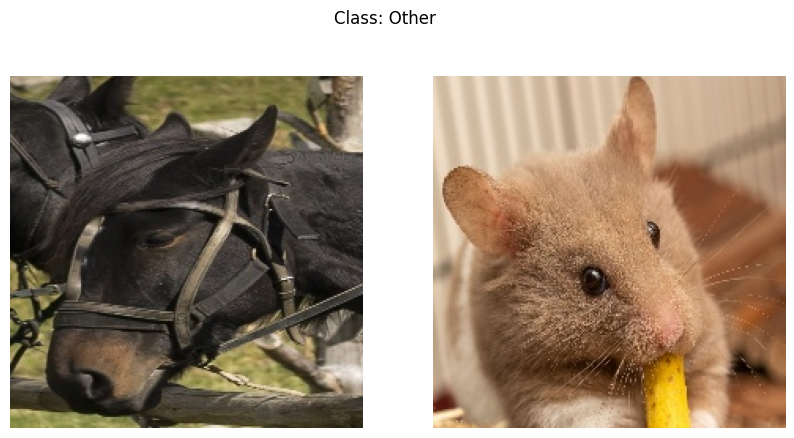

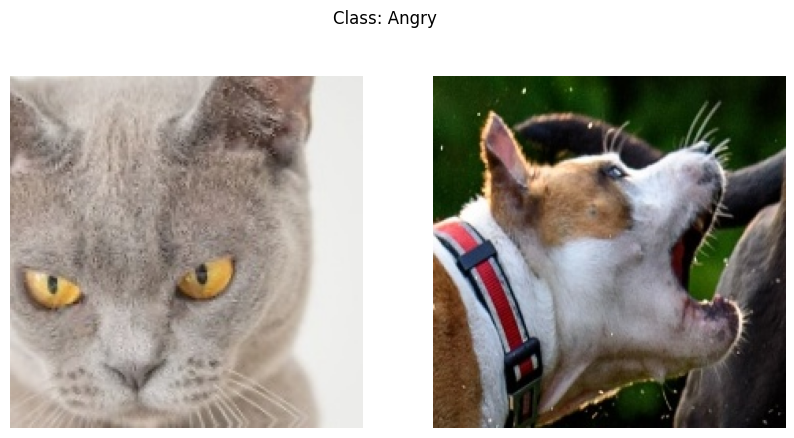

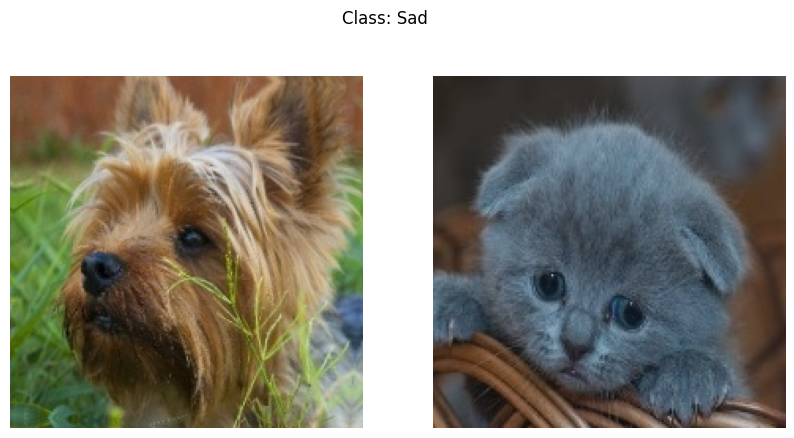

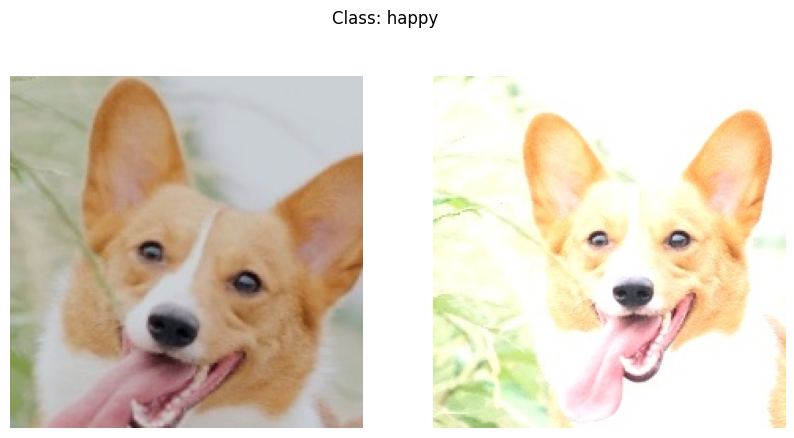

In [1]:
import os
import matplotlib.pyplot as plt
import cv2

# Path to the 'train' folder
train_folder = "/kaggle/input/pets-facial-expression-dataset/Master Folder/train"

# Get class folders inside 'train'
class_folders = [f for f in os.listdir(train_folder) if os.path.isdir(os.path.join(train_folder, f))]

# Display 2 images from each class
for class_name in class_folders:
    class_path = os.path.join(train_folder, class_name)
    images = os.listdir(class_path)[:2]  # Get first 2 images
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(f"Class: {class_name}")
    for i, img_name in enumerate(images):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].axis("off")
    plt.show()


# Data Analysis

Image counts per class in the 'train' folder:
Other: 250
Angry: 250
Sad: 250
happy: 250


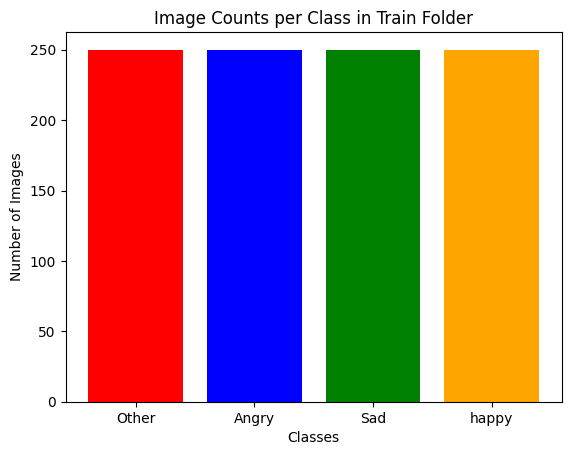

In [2]:
import os
from collections import Counter

# Path to the 'train' folder
train_folder = "/kaggle/input/pets-facial-expression-dataset/Master Folder/train"

# Initialize a dictionary to store counts for each class
class_counts = Counter()

# Loop through each class folder and count the number of images
for class_name in os.listdir(train_folder):
    class_path = os.path.join(train_folder, class_name)
    if os.path.isdir(class_path):
        num_images = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
        class_counts[class_name] = num_images

# Display the counts for each class
print("Image counts per class in the 'train' folder:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

# Optional: Visualize the counts using a bar chart
import matplotlib.pyplot as plt

plt.bar(class_counts.keys(), class_counts.values(), color=['red', 'blue', 'green', 'orange'])
plt.title('Image Counts per Class in Train Folder')
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.show()


# Data Augmentation

In [3]:
# import os
# import cv2
# import albumentations as A
# from tqdm import tqdm

# # Define the path to the 'train' folder and the output augmented folder
# train_folder = "/kaggle/input/pets-dataset"
# augmented_output_folder = "./train_augmented"

# # Create the augmented folder structure
# os.makedirs(augmented_output_folder, exist_ok=True)
# for class_name in os.listdir(train_folder):
#     class_path = os.path.join(train_folder, class_name)
#     if os.path.isdir(class_path):
#         os.makedirs(os.path.join(augmented_output_folder, class_name), exist_ok=True)

# # Define the augmentation pipeline
# augmentation_pipeline = A.Compose([
#     A.HorizontalFlip(p=0.5),
#     A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=30, p=0.5),  # Shift, Scale, and Rotate
#     A.RandomBrightnessContrast(p=0.5),
#     A.Resize(width=128, height=128)  # Resizing to a uniform size for consistency
# ])

# # Apply augmentations to each class folder
# for class_name in os.listdir(train_folder):
#     class_path = os.path.join(train_folder, class_name)
#     if os.path.isdir(class_path):
#         augmented_class_path = os.path.join(augmented_output_folder, class_name)
#         for img_name in tqdm(os.listdir(class_path), desc=f"Augmenting {class_name}"):
#             img_path = os.path.join(class_path, img_name)
#             img = cv2.imread(img_path)
#             img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB

#             # Apply augmentation
#             augmented = augmentation_pipeline(image=img)
#             augmented_img = augmented['image']

#             # Save the augmented image
#             save_path = os.path.join(augmented_class_path, f"aug_{img_name}")
#             cv2.imwrite(save_path, cv2.cvtColor(augmented_img, cv2.COLOR_RGB2BGR))

# print("Data augmentation completed! Augmented images are saved in 'train_augmented'.")


 # VGG16 from scratch model

In [4]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [5]:
# Hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.00001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASSES = 4

In [6]:
# Updated Transformations with Augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),  # Resize to uniform size
    transforms.RandomHorizontalFlip(p=0.5),  # Randomly flip images horizontally
    transforms.RandomRotation(degrees=10),   # Rotate images by up to ±10 degrees
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),  # Random crop and resize
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Randomly adjust color
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Normalize to pre-trained model standards
])

# Validation and Test Transformations (No Augmentation)
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),  # Ensure consistent size
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize for fair comparison
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),  # Ensure consistent size
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize for fair comparison
])

# Dataset and Dataloader
train_dataset = datasets.ImageFolder("/kaggle/input/pets-facial-expression-dataset/Master Folder/train", transform=train_transform)
valid_dataset = datasets.ImageFolder("/kaggle/input/pets-facial-expression-dataset/Master Folder/valid", transform=val_transform)
test_dataset = datasets.ImageFolder("/kaggle/input/pets-facial-expression-dataset/Master Folder/test", transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [7]:
# VGG model arch
class VGGModel(nn.Module):
    def __init__(self, num_classes):
        super(VGGModel, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Block 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes),
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = VGGModel(CLASSES).to(DEVICE)

In [8]:
model

VGGModel(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU()
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (17): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1)

In [14]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Training loop
train_losses, valid_losses, train_accuracies, valid_accuracies = [], [], [], []

for epoch in range(EPOCHS):
    model.train()
    train_loss, train_correct = 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == labels).sum().item()
    
    train_losses.append(train_loss / len(train_loader))
    train_accuracies.append(train_correct / len(train_dataset))
    
    # Validation loop
    model.eval()
    valid_loss, valid_correct = 0, 0
    
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            valid_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            valid_correct += (predicted == labels).sum().item()
    
    valid_losses.append(valid_loss / len(valid_loader))
    valid_accuracies.append(valid_correct / len(valid_dataset))
    
    print(f"Epoch [{epoch+1}/{EPOCHS}], "
          f"Train Loss: {train_losses[-1]:.4f}, Val Loss: {valid_losses[-1]:.4f}, "
          f"Train Acc: {train_accuracies[-1]:.4f}, Val Acc: {valid_accuracies[-1]:.4f}")

Epoch [1/10], Train Loss: 1.3773, Val Loss: 1.3496, Train Acc: 0.3130, Val Acc: 0.3056
Epoch [2/10], Train Loss: 1.3675, Val Loss: 1.3486, Train Acc: 0.3270, Val Acc: 0.2778
Epoch [3/10], Train Loss: 1.3641, Val Loss: 1.3577, Train Acc: 0.3380, Val Acc: 0.2778
Epoch [4/10], Train Loss: 1.3480, Val Loss: 1.3327, Train Acc: 0.3560, Val Acc: 0.3333
Epoch [5/10], Train Loss: 1.3490, Val Loss: 1.3568, Train Acc: 0.3460, Val Acc: 0.3056
Epoch [6/10], Train Loss: 1.3407, Val Loss: 1.3331, Train Acc: 0.3760, Val Acc: 0.3056
Epoch [7/10], Train Loss: 1.3416, Val Loss: 1.3285, Train Acc: 0.3450, Val Acc: 0.3611
Epoch [8/10], Train Loss: 1.3383, Val Loss: 1.3589, Train Acc: 0.3570, Val Acc: 0.2778
Epoch [9/10], Train Loss: 1.3273, Val Loss: 1.3858, Train Acc: 0.3770, Val Acc: 0.2222
Epoch [10/10], Train Loss: 1.3266, Val Loss: 1.2985, Train Acc: 0.3690, Val Acc: 0.3333


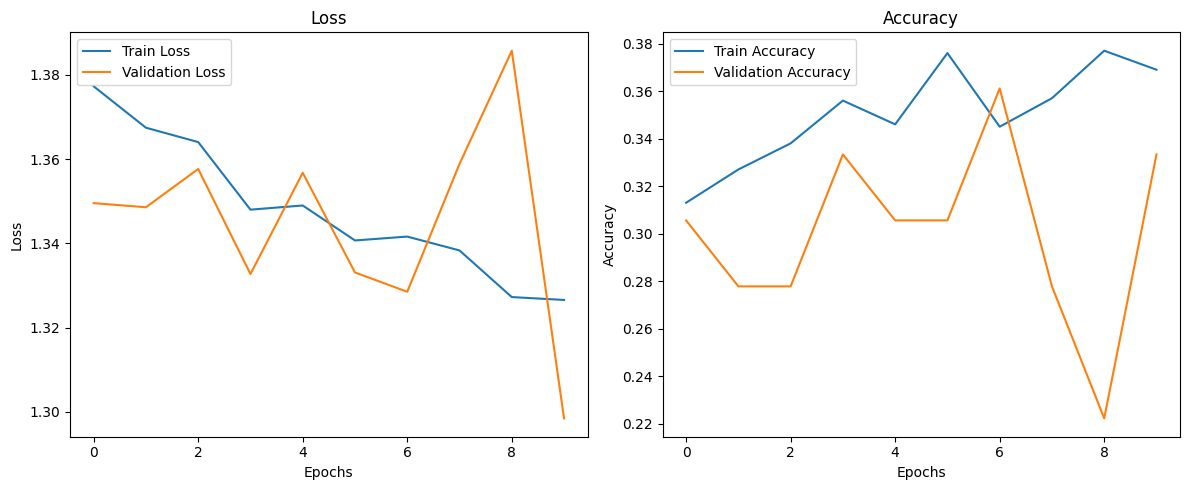

In [15]:
# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(valid_accuracies, label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


Test Accuracy: 0.3421
['Angry', 'Other', 'Sad', 'happy']


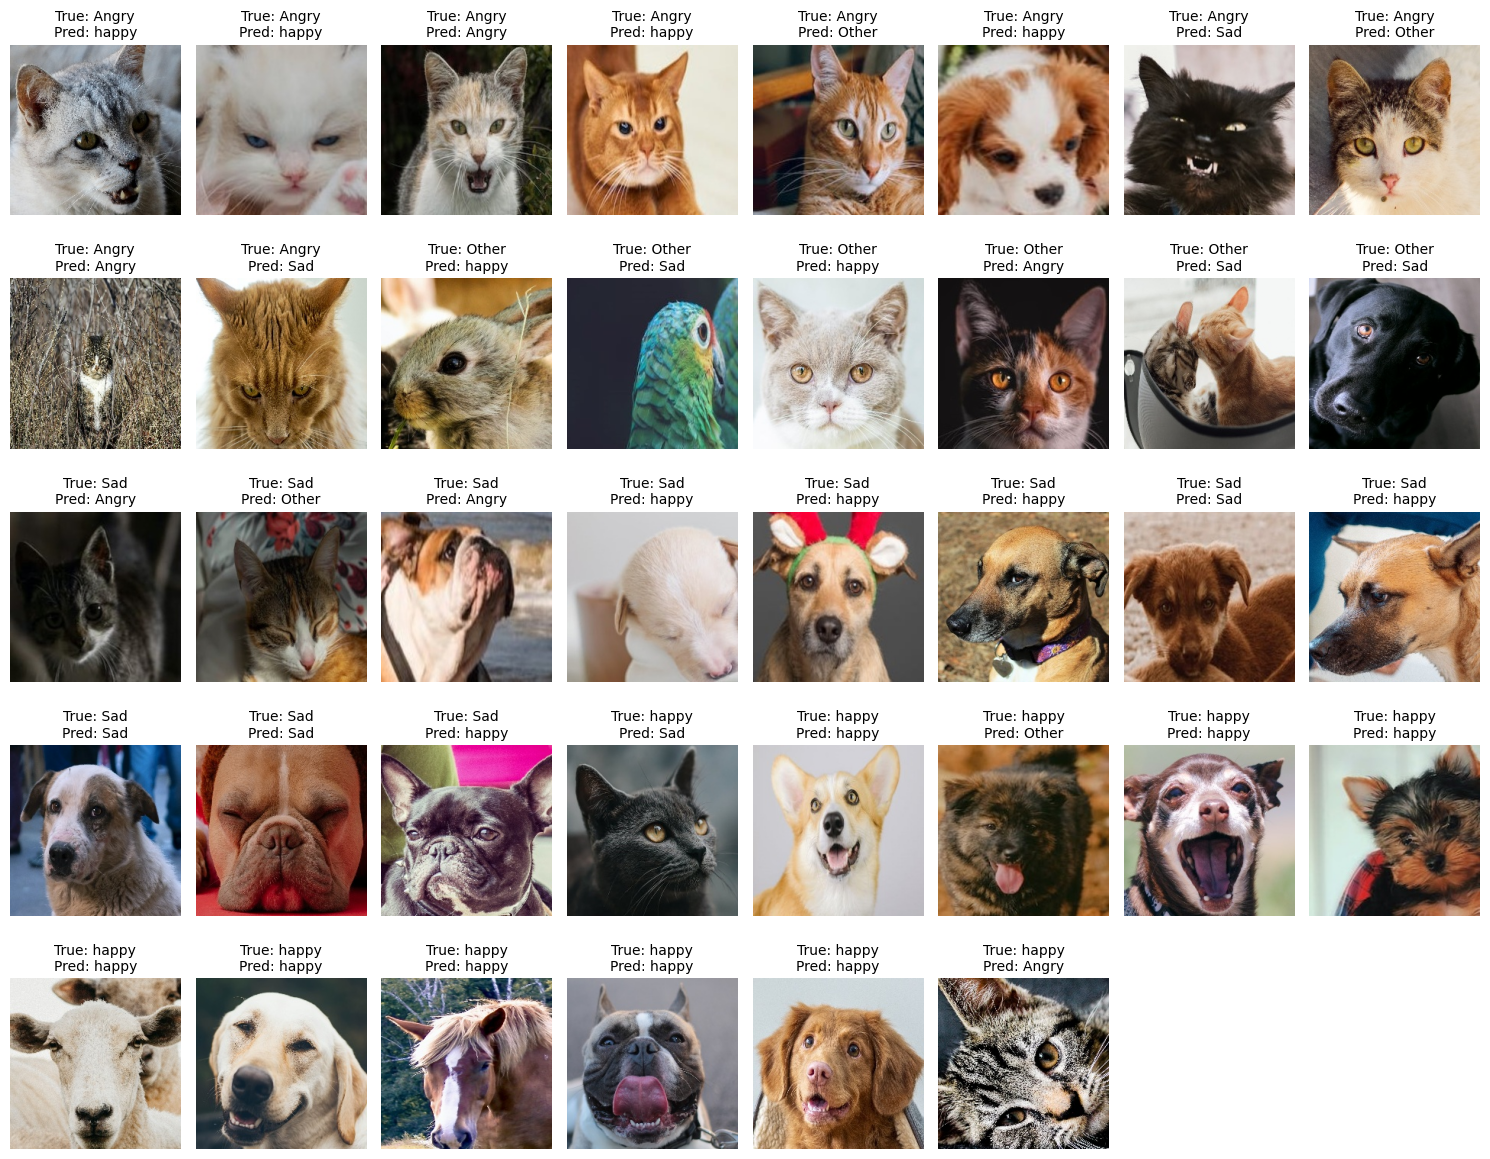

In [16]:
# Testing loop
model.eval()
test_correct = 0
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.append(predicted.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
        test_correct += (predicted == labels).sum().item()

test_accuracy = test_correct / len(test_dataset)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Visualization
class_names = train_dataset.classes
print(class_names)
test_images = [images[0] for images, _ in test_loader]
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# Plot 20 images in a grid layout (4x5)
plt.figure(figsize=(15, 12))  # Adjust figure size for better display
for i in range(len(test_images)):  # Ensure we don't exceed the number of available images
    plt.subplot(5, 8, i + 1)  # Grid layout: 4 rows, 5 columns
    plt.imshow(np.transpose(test_images[i].cpu().numpy(), (1, 2, 0)) * 0.5 + 0.5)  # Denormalize for display
    plt.title(f"True: {class_names[all_labels[i]]}\nPred: {class_names[all_preds[i]]}", fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()


Classification Report:
               precision    recall  f1-score   support

       Angry     0.3333    0.2000    0.2500        10
       Other     0.0000    0.0000    0.0000         6
         Sad     0.3333    0.2727    0.3000        11
       happy     0.4211    0.7273    0.5333        11

    accuracy                         0.3421        38
   macro avg     0.2719    0.3000    0.2708        38
weighted avg     0.3061    0.3421    0.3070        38



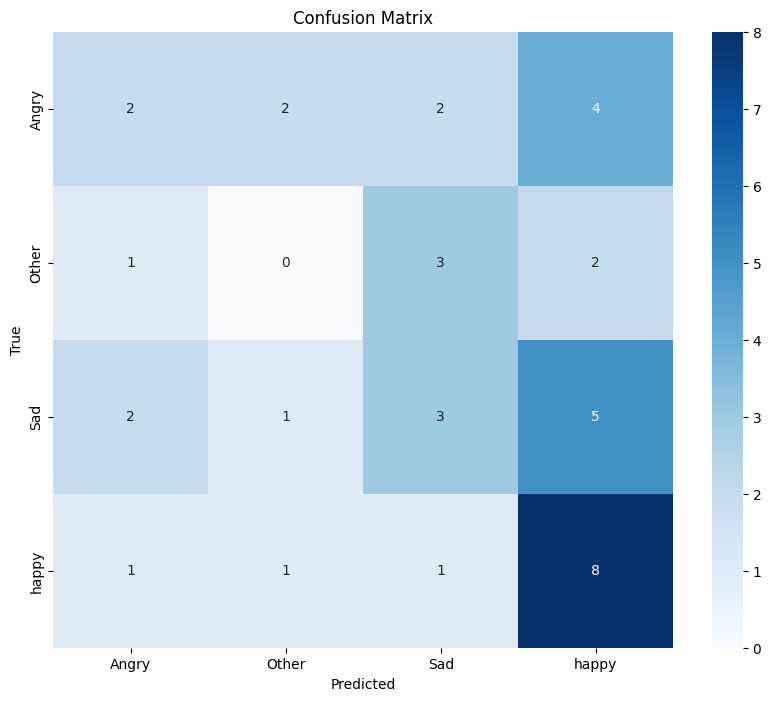

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluation on the test set
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Classification report
report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print("Classification Report:\n", report)

# Confusion matrix
conf_matrix = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# VGG16 pretrained model

Found 1000 images belonging to 4 classes.
Found 36 images belonging to 4 classes.
Found 38 images belonging to 4 classes.
Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 328ms/step - accuracy: 0.2639 - loss: 1.7060 - val_accuracy: 0.2778 - val_loss: 1.3542
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 269ms/step - accuracy: 0.2638 - loss: 1.4860 - val_accuracy: 0.3889 - val_loss: 1.3004
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 276ms/step - accuracy: 0.2956 - loss: 1.4284 - val_accuracy: 0.4444 - val_loss: 1.2686
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 277ms/step - accuracy: 0.3269 - loss: 1.3665 - val_accuracy: 0.4444 - val_loss: 1.2484
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 269ms/step - accuracy: 0.3350 - loss: 1.3637 - val_accuracy: 0.4444 - val_loss: 1.2704
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 275ms/step - accuracy: 0.3491 - loss: 1.3244 - val_accuracy: 0.4722 - val_loss: 1.2291
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 269ms/step - accuracy: 0.4069 - loss: 1.3019 - val_accuracy: 0

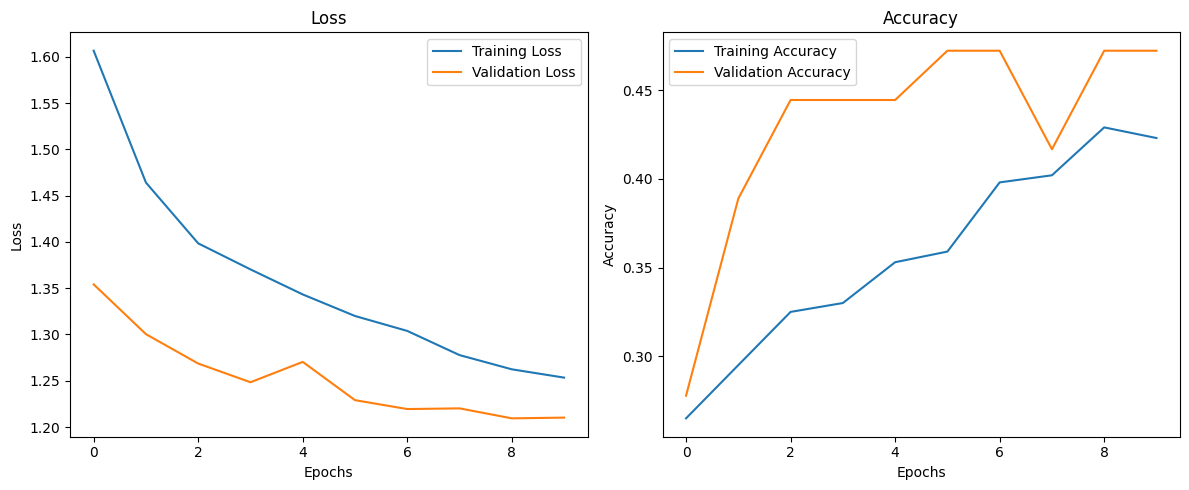

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5206 - loss: 1.2538
Test Accuracy: 0.42
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step


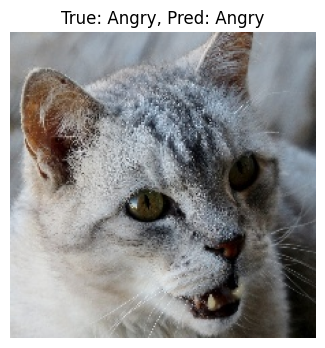

In [33]:
# import tensorflow as tf
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# from tensorflow.keras.applications import VGG16
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Dense, Flatten, Dropout
# from tensorflow.keras.optimizers import Adam
# import matplotlib.pyplot as plt
# import numpy as np

# # Data paths
# train_dir = "/kaggle/input/pets-facial-expression-dataset/Master Folder/train"
# valid_dir = "/kaggle/input/pets-facial-expression-dataset/Master Folder/valid"
# test_dir = "/kaggle/input/pets-facial-expression-dataset/Master Folder/test"

# # Parameters
# IMG_SIZE = (224, 224)
# BATCH_SIZE = 32
# EPOCHS = 10
# CLASSES = 4

# # Data Generators
# # Data Generators with Augmentation
# train_datagen = ImageDataGenerator(
#     rescale=1.0 / 255,
#     rotation_range=30,      # Randomly rotate images by up to 30 degrees
#     width_shift_range=0.2,  # Randomly shift images horizontally by up to 20%
#     height_shift_range=0.2, # Randomly shift images vertically by up to 20%
#     shear_range=0.2,        # Apply shearing transformations
#     zoom_range=0.2,         # Randomly zoom images by up to 20%
#     horizontal_flip=True,   # Randomly flip images horizontally
#     fill_mode='nearest'     # Fill missing pixels with the nearest valid value
# )

# valid_datagen = ImageDataGenerator(rescale=1.0/255)
# test_datagen = ImageDataGenerator(rescale=1.0/255)

# train_generator = train_datagen.flow_from_directory(
#     train_dir,
#     target_size=IMG_SIZE,
#     batch_size=BATCH_SIZE,
#     class_mode='categorical'
# )

# valid_generator = valid_datagen.flow_from_directory(
#     valid_dir,
#     target_size=IMG_SIZE,
#     batch_size=BATCH_SIZE,
#     class_mode='categorical'
# )

# test_generator = test_datagen.flow_from_directory(
#     test_dir,
#     target_size=IMG_SIZE,
#     batch_size=1,
#     class_mode='categorical',
#     shuffle=False
# )

# # Model building
# base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
# for layer in base_model.layers:
#     layer.trainable = False

# x = Flatten()(base_model.output)
# x = Dense(256, activation='relu')(x)
# x = Dropout(0.5)(x)
# output = Dense(CLASSES, activation='softmax')(x)

# model = Model(inputs=base_model.input, outputs=output)
# model.compile(optimizer=Adam(learning_rate=0.00001), loss='categorical_crossentropy', metrics=['accuracy'])

# # Training
# history = model.fit(
#     train_generator,
#     epochs=EPOCHS,
#     validation_data=valid_generator,
#     verbose=1
# )

# # Plotting training history
# plt.figure(figsize=(12, 5))
# plt.subplot(1, 2, 1)
# plt.plot(history.history['loss'], label='Training Loss')
# plt.plot(history.history['val_loss'], label='Validation Loss')
# plt.title('Loss')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.legend()

# plt.subplot(1, 2, 2)
# plt.plot(history.history['accuracy'], label='Training Accuracy')
# plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
# plt.title('Accuracy')
# plt.xlabel('Epochs')
# plt.ylabel('Accuracy')
# plt.legend()

# plt.tight_layout()
# plt.show()

# # Testing
# test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
# print(f"Test Accuracy: {test_accuracy:.2f}")

# # Visualization
# class_labels = list(test_generator.class_indices.keys())
# test_images, test_labels = next(test_generator)

# predictions = model.predict(test_images)
# predicted_classes = np.argmax(predictions, axis=1)
# true_classes = np.argmax(test_labels, axis=1)

# plt.figure(figsize=(10, 10))
# for i in range(min(9, len(test_images))):
#     plt.subplot(3, 3, i + 1)
#     plt.imshow(test_images[i])
#     plt.title(f"True: {class_labels[true_classes[i]]}, Pred: {class_labels[predicted_classes[i]]}")
#     plt.axis('off')
# plt.tight_layout()
# plt.show()
